In [ ]:
import torch
TORCH_VERSION = torch.__version__.split('+')[0]
CUDA_VERSION = 'cpu'

!pip install -q torch_geometric
!pip install -q torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_VERSION}.html


In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc,
    mean_absolute_error, mean_squared_error, r2_score
)

SEED = 13
np.random.seed(SEED)
torch.manual_seed(SEED)


In [ ]:
DATA_PATH = "cleaned_merged_heart_dataset.csv"

df = pd.read_csv("/content/drive/MyDrive/cleaned_merged_heart_dataset.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1888, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
feature_cols = [c for c in df.columns if c != 'target']

scaler = MinMaxScaler()
X = scaler.fit_transform(df[feature_cols].values)
y = df['target'].values.astype(int)

print("Feature matrix shape:", X.shape)
print("Label distribution:", np.bincount(y))


Feature matrix shape: (1888, 13)
Label distribution: [911 977]


In [ ]:
K = 10

nbrs = NearestNeighbors(n_neighbors=K + 1, metric='euclidean').fit(X)
_, indices = nbrs.kneighbors(X)

edge_list = []
for i, neighbors in enumerate(indices):
    for j in neighbors:
        if i != j:
            edge_list.append([i, j])
            edge_list.append([j, i])

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
edge_index = torch.unique(edge_index, dim=1)

print("Number of nodes:", X.shape[0])
print("Number of edges:", edge_index.shape[1])


Number of nodes: 1888
Number of edges: 25050


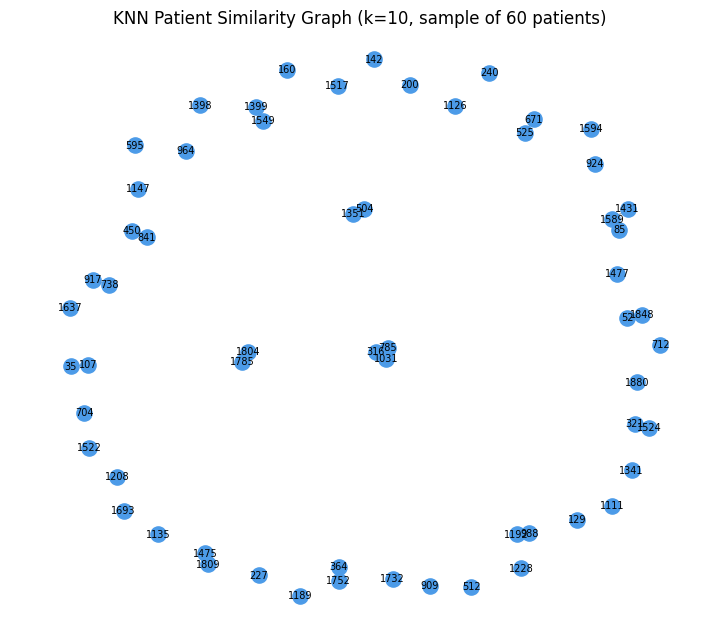

In [ ]:
sample_size = 60
sample_idx = np.random.choice(X.shape[0], sample_size, replace=False)
sample_set = set(sample_idx.tolist())

G = nx.Graph()
G.add_nodes_from(sample_idx.tolist())
for src, dst in edge_index.t().tolist():
    if src in sample_set and dst in sample_set:
        G.add_edge(src, dst)

plt.figure(figsize=(7, 6))
pos = nx.spring_layout(G, seed=SEED)
nx.draw(G, pos, node_size=120, node_color='#4C9BE8', edge_color='#AAAAAA',
        with_labels=True, font_size=7)
plt.title(f"KNN Patient Similarity Graph (k={K}, sample of {sample_size} patients)")
plt.show()


In [ ]:
num_nodes = X.shape[0]
train_idx, test_idx = train_test_split(
    np.arange(num_nodes), test_size=0.2, stratify=y, random_state=SEED
)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx] = True

data = Data(
    x=torch.tensor(X, dtype=torch.float),
    edge_index=edge_index,
    y=torch.tensor(y, dtype=torch.long),
    train_mask=train_mask,
    test_mask=test_mask
)

print(data)


Data(x=[1888, 13], edge_index=[2, 25050], y=[1888], train_mask=[1888], test_mask=[1888])


In [ ]:
class HeartGCN(nn.Module):
    def __init__(self, in_channels, hidden1=32, hidden2=16, num_classes=2, dropout=0.4):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden1)
        self.conv2 = GCNConv(hidden1, hidden2)
        self.fc = nn.Linear(hidden2, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        out = self.fc(x)
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HeartGCN(in_channels=X.shape[1]).to(device)
data = data.to(device)
print(model)


HeartGCN(
  (conv1): GCNConv(13, 32)
  (conv2): GCNConv(32, 16)
  (fc): Linear(in_features=16, out_features=2, bias=True)
)


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

EPOCHS = 200
loss_history = []

model.train()
for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")


Epoch  20 | Loss: 0.5360
Epoch  40 | Loss: 0.4865
Epoch  60 | Loss: 0.4695
Epoch  80 | Loss: 0.4511
Epoch 100 | Loss: 0.4306
Epoch 120 | Loss: 0.4214
Epoch 140 | Loss: 0.3961
Epoch 160 | Loss: 0.3817
Epoch 180 | Loss: 0.3761
Epoch 200 | Loss: 0.3670


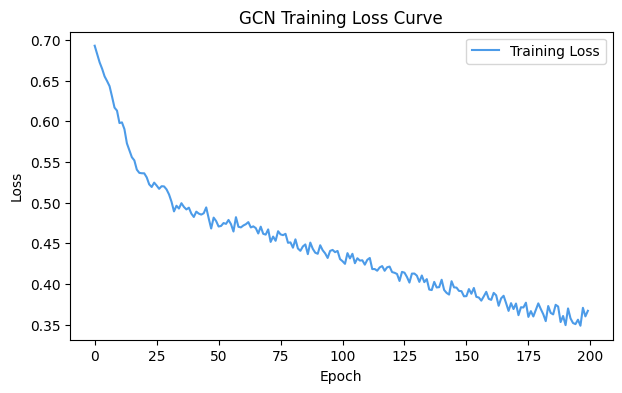

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history, color='#4C9BE8')
plt.title("GCN Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss"])
plt.show()


In [ ]:
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    probs = F.softmax(logits, dim=1)
    preds = logits.argmax(dim=1)

y_true = data.y[data.test_mask].cpu().numpy()
y_pred = preds[data.test_mask].cpu().numpy()
y_prob = probs[data.test_mask][:, 1].cpu().numpy()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5
r2 = r2_score(y_true, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")



Accuracy:  0.8730
Precision: 0.8776
Recall:    0.8776
F1 Score:  0.8776


Bootstrap Confidence Intervals (n=1000 valid resamples out of 1000)
-----------------------------------------------------------------
Accuracy    : 0.8730  (95% CI: 0.8412 - 0.9048)
Precision   : 0.8776  (95% CI: 0.8316 - 0.9242)
Recall      : 0.8776  (95% CI: 0.8298 - 0.9235)
F1 Score    : 0.8776  (95% CI: 0.8430 - 0.9109)
ROC-AUC     : 0.9366  (95% CI: 0.9131 - 0.9584)


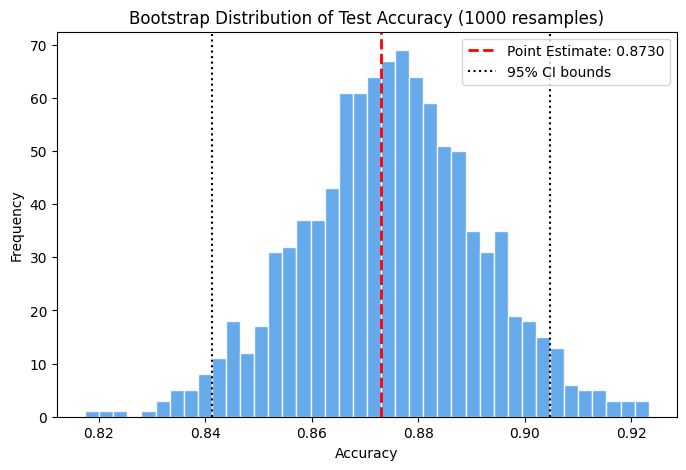

In [ ]:
# ============================================
# Bootstrap Confidence Intervals for Model Metrics
# ============================================
from sklearn.metrics import roc_auc_score

n_bootstraps = 1000
rng = np.random.RandomState(SEED)

n_samples = len(y_true)

# Storage for bootstrapped metrics
boot_acc = []
boot_prec = []
boot_rec = []
boot_f1 = []
boot_auc = []

for i in range(n_bootstraps):
    # Randomly resample test set indices WITH replacement
    indices = rng.randint(0, n_samples, n_samples)

    # Skip iteration if resampled set has only one class (can't compute AUC)
    if len(np.unique(y_true[indices])) < 2:
        continue

    boot_acc.append(accuracy_score(y_true[indices], y_pred[indices]))
    boot_prec.append(precision_score(y_true[indices], y_pred[indices], zero_division=0))
    boot_rec.append(recall_score(y_true[indices], y_pred[indices], zero_division=0))
    boot_f1.append(f1_score(y_true[indices], y_pred[indices], zero_division=0))
    boot_auc.append(roc_auc_score(y_true[indices], y_prob[indices]))

# Convert to numpy arrays for percentile calculation
boot_acc = np.array(boot_acc)
boot_prec = np.array(boot_prec)
boot_rec = np.array(boot_rec)
boot_f1 = np.array(boot_f1)
boot_auc = np.array(boot_auc)

def report_ci(name, values, point_estimate):
    lower = np.percentile(values, 2.5)
    upper = np.percentile(values, 97.5)
    print(f"{name:12s}: {point_estimate:.4f}  (95% CI: {lower:.4f} - {upper:.4f})")

print(f"Bootstrap Confidence Intervals (n={len(boot_acc)} valid resamples out of {n_bootstraps})")
print("-" * 65)
report_ci("Accuracy", boot_acc, acc)
report_ci("Precision", boot_prec, prec)
report_ci("Recall", boot_rec, rec)
report_ci("F1 Score", boot_f1, f1)
report_ci("ROC-AUC", boot_auc, auc(*roc_curve(y_true, y_prob)[:2]))

# ============================================
# Visualization: Distribution of Bootstrapped Accuracy
# ============================================
plt.figure(figsize=(8, 5))
plt.hist(boot_acc, bins=40, color='#4C9BE8', edgecolor='white', alpha=0.85)
plt.axvline(acc, color='red', linestyle='--', linewidth=2, label=f'Point Estimate: {acc:.4f}')
plt.axvline(np.percentile(boot_acc, 2.5), color='black', linestyle=':', linewidth=1.5, label='95% CI bounds')
plt.axvline(np.percentile(boot_acc, 97.5), color='black', linestyle=':', linewidth=1.5)
plt.title("Bootstrap Distribution of Test Accuracy (1000 resamples)")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.legend()
plt.show()

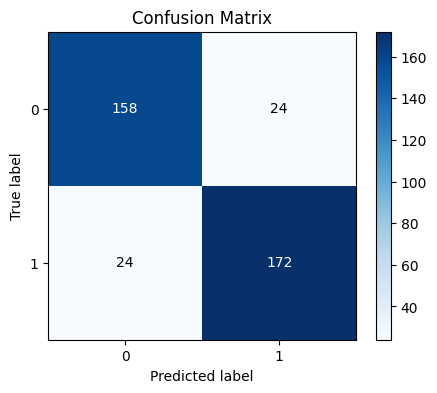

In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')

ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix")
plt.colorbar(im)
plt.show()


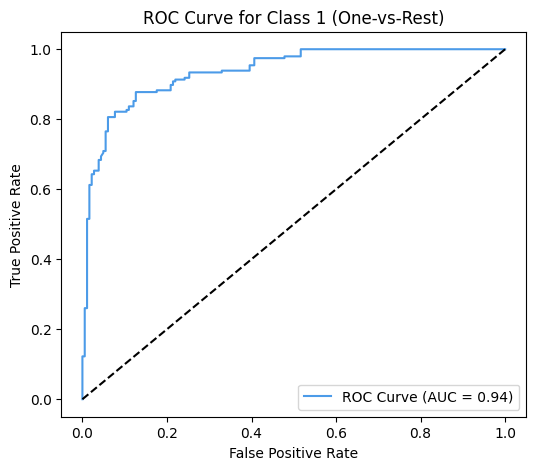

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#4C9BE8', label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='black')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Class 1 (One-vs-Rest)")
plt.legend(loc='lower right')
plt.show()
